# EDA & Eksplorasi Dataset FAQ Chatbot

Notebook ini bertujuan untuk:
1. Memahami struktur dataset FAQ
2. Eksplorasi distribusi kategori dan pertanyaan
3. Analisis kemiripan antar pertanyaan
4. Uji coba preprocessing teks Bahasa Indonesia

---

## 1. Import Library & Load Data

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.size']        = 11

# Load dataset
with open('../data/faq.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

faqs = data['faq']
print(f'Total FAQ entries: {len(faqs)}')
print(f'Kategori: {set(f["kategori"] for f in faqs)}')

Total FAQ entries: 15
Kategori: {'Pembayaran', 'Pengembalian', 'Promo', 'Pengiriman', 'Akun', 'Produk', 'Komplain'}


## 2. Buat DataFrame Eksplorasi

In [2]:
# Flatten semua pertanyaan (termasuk variasi)
rows = []
for faq in faqs:
    # Pertanyaan utama
    rows.append({'id': faq['id'], 'kategori': faq['kategori'],
                 'pertanyaan': faq['pertanyaan'], 'tipe': 'utama'})
    # Variasi
    for v in faq.get('variasi', []):
        rows.append({'id': faq['id'], 'kategori': faq['kategori'],
                     'pertanyaan': v, 'tipe': 'variasi'})

df = pd.DataFrame(rows)
print(f'Total pertanyaan (termasuk variasi): {len(df)}')
print(f'Distribusi tipe:')
print(df['tipe'].value_counts())
df.head(10)

Total pertanyaan (termasuk variasi): 90
Distribusi tipe:
tipe
variasi    75
utama      15
Name: count, dtype: int64


,id,kategori,pertanyaan,tipe
0,1,Pengiriman,Berapa lama waktu pengiriman pesanan saya?,utama
1,1,Pengiriman,Kapan pesanan saya sampai?,variasi
2,1,Pengiriman,Estimasi pengiriman berapa hari?,variasi
3,1,Pengiriman,Berapa lama paket dikirim?,variasi
4,1,Pengiriman,Pengiriman butuh waktu berapa lama?,variasi
5,1,Pengiriman,Kapan barang saya tiba?,variasi
6,2,Pengiriman,Apakah ada layanan pengiriman ekspres?,utama
7,2,Pengiriman,Bisa kirim hari ini?,variasi
8,2,Pengiriman,Ada pengiriman same day?,variasi
9,2,Pengiriman,Ekspres ada tidak?,variasi


In [3]:
# Statistik per kategori
print('=== STATISTIK PER KATEGORI ===')
stats = df.groupby('kategori').agg(
    total_pertanyaan=('pertanyaan', 'count'),
    pertanyaan_utama=('tipe', lambda x: (x=='utama').sum()),
    total_variasi=('tipe', lambda x: (x=='variasi').sum())
).reset_index()
display(stats)

=== STATISTIK PER KATEGORI ===


,kategori,total_pertanyaan,pertanyaan_utama,total_variasi
0,Akun,12,2,10
1,Komplain,6,1,5
2,Pembayaran,18,3,15
3,Pengembalian,12,2,10
4,Pengiriman,18,3,15
5,Produk,12,2,10
6,Promo,12,2,10


## 3. Visualisasi Distribusi

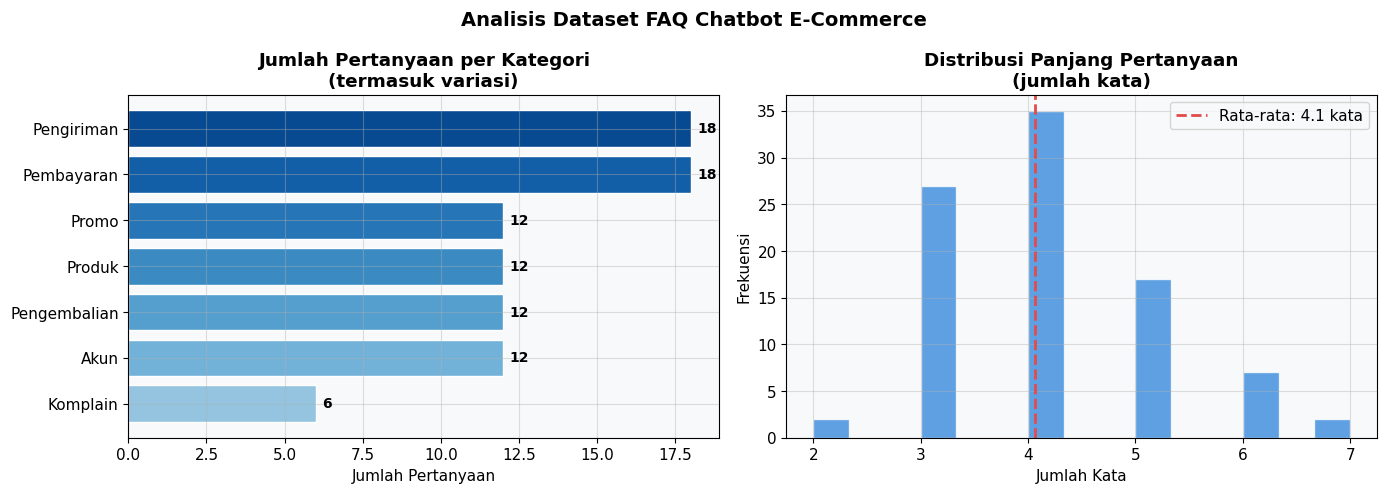

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Dataset FAQ Chatbot E-Commerce', fontsize=14, fontweight='bold')

# -- Distribusi kategori --
cat_counts = df.groupby('kategori')['pertanyaan'].count().sort_values(ascending=True)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_counts)))
bars = axes[0].barh(cat_counts.index, cat_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Jumlah Pertanyaan')
axes[0].set_title('Jumlah Pertanyaan per Kategori\n(termasuk variasi)', fontweight='bold')

# -- Distribusi panjang pertanyaan --
df['panjang'] = df['pertanyaan'].apply(lambda x: len(x.split()))
axes[1].hist(df['panjang'], bins=15, color='#378ADD', alpha=0.8, edgecolor='white')
axes[1].axvline(df['panjang'].mean(), color='#E24B4A', linestyle='--',
                linewidth=2, label=f"Rata-rata: {df['panjang'].mean():.1f} kata")
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Panjang Pertanyaan\n(jumlah kata)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_eda_faq.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Analisis TF-IDF & Cosine Similarity

In [5]:
# Fungsi preprocessing sederhana Bahasa Indonesia
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Stopwords Bahasa Indonesia sederhana
    stopwords = {'yang','dan','di','ke','dari','ini','itu','tidak','ada',
                 'dengan','untuk','pada','atau','juga','sudah','saya',
                 'kami','kita','bisa','akan','adalah','apakah','bagaimana',
                 'berapa','cara','gimana','dong','ya','aja','sih','lah'}
    return ' '.join(w for w in text.split() if w not in stopwords)

# Ambil semua pertanyaan
all_questions = df['pertanyaan'].tolist()
preprocessed  = [preprocess(q) for q in all_questions]

# TF-IDF vectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=1)
tfidf_matrix = vectorizer.fit_transform(preprocessed)

print(f'Shape TF-IDF matrix: {tfidf_matrix.shape}')
print(f'Jumlah fitur (kata/bigram): {len(vectorizer.get_feature_names_out())}')
print()

# Top 20 fitur TF-IDF paling penting
feature_names = vectorizer.get_feature_names_out()
tfidf_scores  = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx       = tfidf_scores.argsort()[::-1][:20]
print('Top 20 fitur TF-IDF:')
for i, idx in enumerate(top_idx, 1):
    print(f'  {i:2}. {feature_names[idx]:<30} skor: {tfidf_scores[idx]:.4f}')

Shape TF-IDF matrix: (90, 320)
Jumlah fitur (kata/bigram): 320

Top 20 fitur TF-IDF:
   1. barang                         skor: 0.0403
   2. pengiriman                     skor: 0.0295
   3. produk                         skor: 0.0274
   4. apa                            skor: 0.0270
   5. pembayaran                     skor: 0.0269
   6. caranya                        skor: 0.0220
   7. pesanan                        skor: 0.0213
   8. password                       skor: 0.0201
   9. poin                           skor: 0.0188
  10. akun                           skor: 0.0184
  11. bayar                          skor: 0.0180
  12. kode                           skor: 0.0172
  13. voucher                        skor: 0.0169
  14. aman                           skor: 0.0167
  15. ekspres                        skor: 0.0160
  16. dikembalikan                   skor: 0.0157
  17. mana                           skor: 0.0157
  18. program                        skor: 0.0154
  19. lupa     

In [6]:
# Uji coba: masukkan pertanyaan pengguna dan lihat hasilnya
test_queries = [
    'kapan barang saya sampai',
    'cara bayar pakai gopay',
    'mau kembalikan produk rusak',
    'lupa password akun',
    'barang ori tidak'
]

print('=== UJI COBA PENCARIAN FAQ ===')
print()
for query in test_queries:
    q_vec = vectorizer.transform([preprocess(query)])
    sims  = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top   = sims.argsort()[::-1][0]
    print(f'Query   : "{query}"')
    print(f'Match   : "{all_questions[top]}"')
    print(f'Kategori: {df.iloc[top]["kategori"]}')
    print(f'Skor    : {sims[top]:.4f}')
    print('-' * 55)

=== UJI COBA PENCARIAN FAQ ===

Query   : "kapan barang saya sampai"
Match   : "Kapan barang saya tiba?"
Kategori: Pengiriman
Skor    : 0.6015
-------------------------------------------------------
Query   : "cara bayar pakai gopay"
Match   : "Bisa bayar pakai apa?"
Kategori: Pembayaran
Skor    : 0.7959
-------------------------------------------------------
Query   : "mau kembalikan produk rusak"
Match   : "Mau kembalikan produk bagaimana?"
Kategori: Pengembalian
Skor    : 1.0000
-------------------------------------------------------
Query   : "lupa password akun"
Match   : "Lupa password, bagaimana cara reset?"
Kategori: Akun
Skor    : 0.6658
-------------------------------------------------------
Query   : "barang ori tidak"
Match   : "Produk ori atau KW?"
Kategori: Produk
Skor    : 0.4018
-------------------------------------------------------


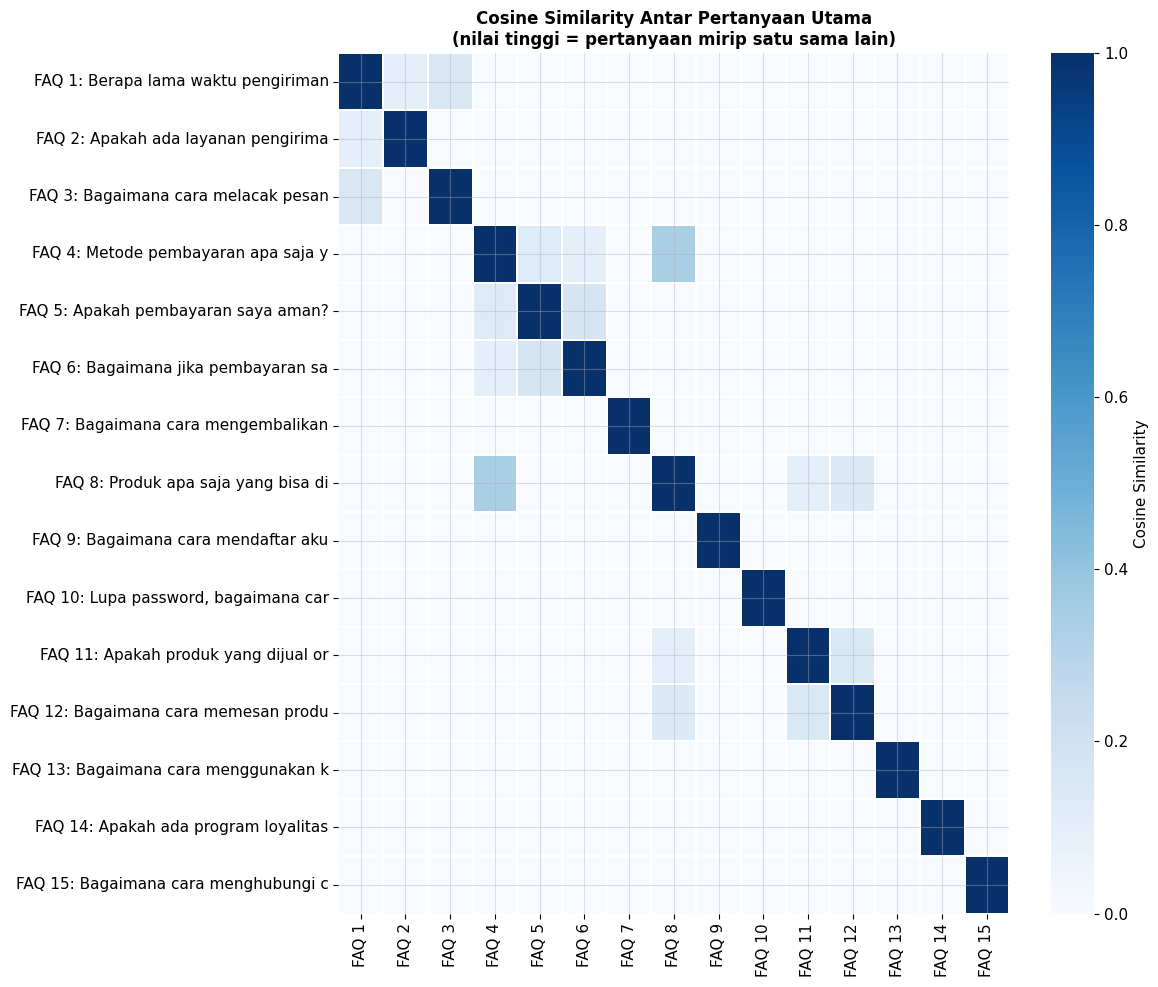

✅ EDA selesai! Lanjut ke notebook model_chatbot.ipynb


In [7]:
# Heatmap cosine similarity antar pertanyaan utama
utama_df  = df[df['tipe'] == 'utama'].reset_index(drop=True)
utama_vec = vectorizer.transform([preprocess(q) for q in utama_df['pertanyaan']])
sim_matrix = cosine_similarity(utama_vec)

fig, ax = plt.subplots(figsize=(12, 10))
labels  = [f"{r['id']}. {r['pertanyaan'][:30]}..." for _, r in utama_df.iterrows()]
sns.heatmap(sim_matrix, annot=False, cmap='Blues',
            xticklabels=[f"FAQ {i}" for i in utama_df['id']],
            yticklabels=[f"FAQ {i}: {r[:28]}" for i, r in zip(utama_df['id'], utama_df['pertanyaan'])],
            linewidths=0.3, linecolor='white', ax=ax,
            cbar_kws={'label': 'Cosine Similarity'})
ax.set_title('Cosine Similarity Antar Pertanyaan Utama\n(nilai tinggi = pertanyaan mirip satu sama lain)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_similarity_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print('✅ EDA selesai! Lanjut ke notebook model_chatbot.ipynb')